# Tutorial 03 - From Continuous EEG Segments to Power Spectra

This notebook computes power spectral density (PSD) from clean segments using Welch's method, then compares these PSDs against precomputed spectra in the `.mat` file (`EEG_specs`, `EEG_frequency`).

In [1]:
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.signal import welch
import matplotlib.pyplot as plt
from pathlib import Path

mat_path = Path('..') / 'data' / 'MGH4J_sid001_1d8_20130718_075948.mat'
out_dir = Path('..') / 'outputs'
clean_pool_path = out_dir / 'clean_segment_pool.csv'

mat = sio.loadmat(str(mat_path), squeeze_me=True, struct_as_record=False)
bipolar = np.asarray(mat['EEG_segs_bipolar'])
channel_names = [str(x).strip() for x in np.asarray(mat['channel_names']).ravel()]
Fs = float(mat['Fs'])
stored_specs = np.asarray(mat['EEG_specs'])
stored_freq = np.asarray(mat['EEG_frequency']).ravel()

if clean_pool_path.exists():
    clean_pool_df = pd.read_csv(clean_pool_path)
    clean_segments = clean_pool_df['segment_index'].astype(int).to_numpy()
else:
    seg_labels = [str(x).strip() for x in np.asarray(mat['seg_masks']).ravel()]
    clean_segments = np.array([i for i, lbl in enumerate(seg_labels) if lbl == 'normal'], dtype=int)

print('Loaded segments:', bipolar.shape[0])
print('Clean segments available:', len(clean_segments))
print('Stored spectra shape:', stored_specs.shape)
print('Stored frequency bins:', stored_freq.shape)

Loaded segments: 10000
Clean segments available: 6827
Stored spectra shape: (10000, 148, 18)
Stored frequency bins: (148,)


## 1) Welch parameter choices (explicit)

Welch parameters control the PSD estimate:
- `nperseg`: window length in samples (frequency resolution is approximately `Fs / nperseg`)
- `noverlap`: overlap between adjacent windows
- `window`: taper shape (Hann here)
- `detrend`: remove mean trend before FFT

We start with 2-second windows (`nperseg = 400` at 200 Hz).

In [2]:
nperseg = 400
noverlap = 200
window = 'hann'
detrend = 'constant'

freq_res_hz = Fs / nperseg
print('Welch settings:')
print('  nperseg =', nperseg)
print('  noverlap =', noverlap)
print('  window =', window)
print('  detrend =', detrend)
print('  Approx frequency resolution = {:.3f} Hz'.format(freq_res_hz))

Welch settings:
  nperseg = 400
  noverlap = 200
  window = hann
  detrend = constant
  Approx frequency resolution = 0.500 Hz


## 2) Compute Welch PSDs for selected clean segments

For speed and readability, we start with a subset of clean segments. Increase `max_segments` to analyze more data.

In [3]:
max_segments = 300
sel_segments = clean_segments[:max_segments]
n_channels = bipolar.shape[1]

all_psd = []
freqs_ref = None

for seg_idx in sel_segments:
    seg_data = bipolar[seg_idx]  # shape: channels x samples
    seg_psd = []
    for ch in range(n_channels):
        freqs, psd = welch(
            seg_data[ch],
            fs=Fs,
            window=window,
            nperseg=nperseg,
            noverlap=noverlap,
            detrend=detrend,
            scaling='density'
        )
        seg_psd.append(psd)
    seg_psd = np.asarray(seg_psd)
    all_psd.append(seg_psd)
    if freqs_ref is None:
        freqs_ref = freqs

all_psd = np.asarray(all_psd)  # segments x channels x frequencies
print('PSD array shape (segments x channels x freq):', all_psd.shape)
print('Frequency range: {:.2f} to {:.2f} Hz'.format(freqs_ref[0], freqs_ref[-1]))

PSD array shape (segments x channels x freq): (300, 18, 201)
Frequency range: 0.00 to 100.00 Hz


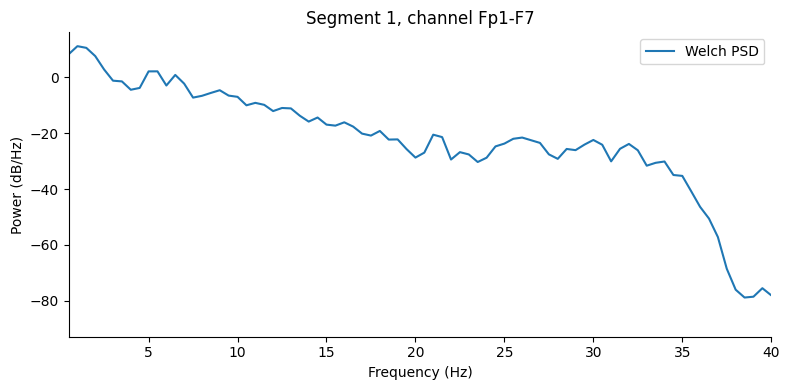

In [4]:
seg_plot = int(sel_segments[0])
ch_plot = 0

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freqs_ref, 10 * np.log10(all_psd[0, ch_plot] + 1e-20), label='Welch PSD')
ax.set_xlim(0.5, 40)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (dB/Hz)')
ax.set_title(f'Segment {seg_plot}, channel {channel_names[ch_plot]}')
ax.spines[['top', 'right']].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

## 3) Compare computed PSDs to stored spectra

Stored spectra may use slightly different preprocessing or Welch settings. We compare shapes and quantify differences with mean absolute error in dB over a shared frequency range.

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: mae_db, dtype: float64


/var/folders/dh/kbd41xgs21s3lms3cgc7_t1w0000gr/T/ipykernel_72514/1883786868.py:9: RuntimeWarning: invalid value encountered in log10
  mae_db = np.mean(np.abs(10 * np.log10(computed + 1e-20) - 10 * np.log10(stored + 1e-20)))
/opt/miniconda3/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7104: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/opt/miniconda3/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7105: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

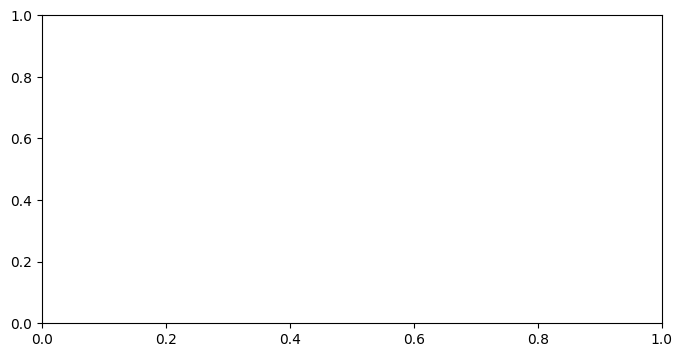

In [5]:
common_mask = (freqs_ref >= stored_freq.min()) & (freqs_ref <= stored_freq.max())
freqs_common = freqs_ref[common_mask]

compare_rows = []
for local_i, seg_idx in enumerate(sel_segments[:50]):
    for ch in range(n_channels):
        computed = np.interp(stored_freq, freqs_ref, all_psd[local_i, ch])
        stored = stored_specs[seg_idx, :, ch]
        mae_db = np.mean(np.abs(10 * np.log10(computed + 1e-20) - 10 * np.log10(stored + 1e-20)))
        compare_rows.append((int(seg_idx), int(ch), float(mae_db)))

compare_df = pd.DataFrame(compare_rows, columns=['segment_index', 'channel_index', 'mae_db'])
compare_df['channel'] = compare_df['channel_index'].map(lambda i: channel_names[i])
print(compare_df['mae_db'].describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(compare_df['mae_db'], bins=40, alpha=0.8)
ax.set_xlabel('MAE between computed and stored PSD (dB)')
ax.set_ylabel('Count')
ax.set_title('PSD agreement summary (first 50 clean segments)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
seg_idx = int(sel_segments[0])
ch_idx = 0

computed_interp = np.interp(stored_freq, freqs_ref, all_psd[0, ch_idx])
stored = stored_specs[seg_idx, :, ch_idx]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(stored_freq, 10 * np.log10(computed_interp + 1e-20), label='Computed Welch')
ax.plot(stored_freq, 10 * np.log10(stored + 1e-20), label='Stored EEG_specs', alpha=0.8)
ax.set_xlim(0.5, 40)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (dB/Hz)')
ax.set_title(f'PSD comparison: segment {seg_idx}, channel {channel_names[ch_idx]}')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 4) Inspect PSD variation across channels and segments

We summarize PSD variability two ways:
1. Median PSD per channel across selected segments
2. Distribution of alpha-band power (8-12 Hz) across segments

In [ ]:
median_psd_by_channel = np.median(all_psd, axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
for ch in range(n_channels):
    ax.plot(freqs_ref, 10 * np.log10(median_psd_by_channel[ch] + 1e-20), linewidth=0.8, alpha=0.8, label=channel_names[ch])
ax.set_xlim(0.5, 40)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Median PSD (dB/Hz)')
ax.set_title('Median Welch PSD per channel (selected clean segments)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

alpha_mask = (freqs_ref >= 8) & (freqs_ref <= 12)
alpha_power = np.mean(all_psd[:, :, alpha_mask], axis=2)
alpha_df = pd.DataFrame(alpha_power, columns=channel_names)

fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot([alpha_df[c] for c in channel_names], labels=channel_names, showfliers=False)
ax.set_xticklabels(channel_names, rotation=60, ha='right')
ax.set_ylabel('Mean power 8-12 Hz (linear units)')
ax.set_title('Alpha-band power variation across channels')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
comparison_path = out_dir / 'psd_comparison_metrics.csv'
compare_df.to_csv(comparison_path, index=False)
print('Saved:', comparison_path.resolve())

## Summary

- We computed Welch PSDs explicitly from clean EEG segments.
- We compared computed PSDs with stored spectra and quantified differences.
- We inspected PSD variation across channels and segments.

In Tutorial 04, we move from isolated segments to longer stretches for time-frequency analysis and quasi-stationarity checks.